# Steps 7 & 8: Anomaly Segmentation Evaluation

This notebook evaluates both **Pixel-based** (ERFNet) and **Mask-based** (EoMT) models for anomaly segmentation across several benchmarks, including SMIYC and Fishyscapes.

## Objectives:
1. **Evaluate ERFNet (Pixel-based):** MSP, MaxLogit, and Max Entropy.
2. **Evaluate EoMT (Mask-based):** MSP, MaxLogit, Max Entropy, and RbA across 3 checkpoints.
3. **Temperature Scaling Search:** Optimize MSP scores using the cached "Smart Trick" logic.
4. **Generate Results Tables:** Produce the exact tables requested in the project guide.

In [1]:
# Reinstall ood_metrics and jsonargparse after fixing numpy
!pip install ood_metrics lightning gitignore_parser > /dev/null
!pip install -U 'jsonargparse[signatures]>=4.27.7' > /dev/null
!pip install --upgrade torchao > /dev/null


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4

In [3]:
!pip uninstall -y pandas numpy &> /dev/null
!pip install numpy pandas &> /dev/null

In [1]:
import os, sys
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive

os.makedirs('/content/drive', exist_ok=True)
drive.mount('/content/drive', force_remount=True)
PROJECT_ROOT = '/content/drive/MyDrive/FundGitHubProject'
for p in (PROJECT_ROOT, os.path.join(PROJECT_ROOT, 'eomt')):
    if p not in sys.path:
        sys.path.insert(0, p)

if not os.path.exists('/content/Fundamental_Project'):
    os.symlink(PROJECT_ROOT, '/content/Fundamental_Project')

os.chdir(PROJECT_ROOT)

from posthoc_metrics import (
    get_pixel_msp, get_pixel_max_logit, get_pixel_entropy,
    get_mask_msp, get_mask_max_logit, get_mask_entropy, get_mask_rba,
    compute_metrics, cache_model_outputs, fast_temperature_search,
)
from eomt.checkpoint_utils import get_finetuned_model, get_eomt_cityscape, get_erfnet_model

# Anomaly validation datasets — downloaded separately into eval/Validation_Dataset/
# on Colab. See README for download instructions.
from eval.Validation_Dataset import anomaly_datasets

Mounted at /content/drive/MyDrive/


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
DATASETS = {
    'SMIYC RA-21':  'RoadAnomaly21',
    'SMIYC RO-21':  'RoadObstacle21',
    'FS L&F':       'FS_LostFound',
    'FS Static':    'FS_Static',
    'Road Anomaly': 'RoadAnomaly',
}

"""dataloaders = {}
for name, key in DATASETS.items():
    dm = anomaly_datasets.AnomalyDataModule(dataset_name=key, img_size=(640, 640))
    dm.setup()
    dataloaders[name] = dm.val_dataloader()
    print(f'  {name}: {len(dataloaders[name])} batches')"""

# For ERFNet — (512, 1024)
dataloaders_erfnet = {}
for ds_name, ds_key in DATASETS.items():
    dm = anomaly_datasets.AnomalyDataModule(ds_key, batch_size=1, img_size=(512, 1024))
    dm.setup()
    dataloaders_erfnet[ds_name] = dm.val_dataloader()

# For EoMT — (640, 640)
dataloaders_eomt = {}
for ds_name, ds_key in DATASETS.items():
    dm = anomaly_datasets.AnomalyDataModule(ds_key, batch_size=1, img_size=(640, 640))
    dm.setup()
    dataloaders_eomt[ds_name] = dm.val_dataloader()


In [4]:
# Paths to model weights — update if your folder layout differs
CKPT = {
    'ERFNet':      'trained_models/erfnet_pretrained.pth',
    'COCO':        'eomt/eomt_weights/eomt_coco.bin',
    'Cityscapes':  'eomt/eomt_weights/eomt_cityscapes.bin',
    # Fine-tuned: best checkpoint from Step 5 experiments
    'Fine-tuned': 'best_eval_checkpoints/OVERALL_CHAMPION_Exp3_mIoU_75.39.ckpt',
}
print('Checkpoints:')
for k, v in CKPT.items():
    status = '✅' if v and os.path.exists(v) else '❌ missing'
    print(f'  {k}: {v}  {status}')


Checkpoints:
  ERFNet: trained_models/erfnet_pretrained.pth  ✅
  COCO: eomt/eomt_weights/eomt_coco.bin  ✅
  Cityscapes: eomt/eomt_weights/eomt_cityscapes.bin  ✅
  Fine-tuned: best_eval_checkpoints/OVERALL_CHAMPION_Exp3_mIoU_75.39.ckpt  ✅


## Step 7 — Pixel-based baselines (ERFNet)

In [5]:
def evaluate_pixel_model(model, dataloader, method_name, temperature=1.0):
    """Single forward pass per image; all scoring is done on the logits."""
    model.eval()
    scoring_fns = {
        'MSP':         lambda l: get_pixel_msp(l, temperature=temperature),
        'MaxLogit':    lambda l: get_pixel_max_logit(l),
        'Max Entropy': lambda l: get_pixel_entropy(l, temperature=temperature),
    }
    fn = scoring_fns[method_name]
    all_scores, all_gts = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f'ERFNet {method_name}', leave=False):
            img    = batch['image'].to(device)
            gt     = batch['label']
            logits = model(img)
            score  = fn(logits)
            if score.shape[-2:] != gt.shape[-2:]:
                score = torch.nn.functional.interpolate(
                    score.unsqueeze(1), size=gt.shape[-2:], mode='bilinear'
                ).squeeze(1)
            all_scores.append(score.cpu().numpy().flatten())
            all_gts.append(gt.numpy().flatten())

    return compute_metrics(np.concatenate(all_scores), np.concatenate(all_gts))


erfnet = get_erfnet_model(CKPT['ERFNet'], device=str(device))

pixel_results = {}
for ds_name, loader in dataloaders_erfnet.items():
    pixel_results[ds_name] = {}
    for method in ['MSP', 'MaxLogit', 'Max Entropy']:
        pixel_results[ds_name][method] = evaluate_pixel_model(erfnet, loader, method)

df_pixel = pd.DataFrame(
    {(ds, m): pixel_results[ds][m] for ds in pixel_results for m in pixel_results[ds]}
).T
print(df_pixel.to_string())



--- Initializing ErfNet Architecture ---
Loading weights from: trained_models/erfnet_pretrained.pth
✅ ErfNet Model ready for inference.


                             auprc     fpr95
SMIYC RA-21  MSP          0.290951  0.625492
             MaxLogit     0.383196  0.593371
             Max Entropy  0.309686  0.626583
SMIYC RO-21  MSP          0.027100  0.652250
             MaxLogit     0.046266  0.484434
             Max Entropy  0.030444  0.659116
FS L&F       MSP          0.017320  0.505626
             MaxLogit     0.032811  0.454526
             Max Entropy  0.025623  0.501268
FS Static    MSP          0.050333  0.409047
             MaxLogit     0.062681  0.396529
             Max Entropy  0.058881  0.406379
Road Anomaly MSP          0.120461  0.825716
             MaxLogit     0.153668  0.721441
             Max Entropy  0.123409  0.827198


## Step 8 — Mask-based baselines (EoMT)

Model outputs are **cached to disk once** per (model, dataset) pair.
All four scoring methods (MSP, MaxLogit, Max Entropy, RbA) are then computed
from the cache in seconds — no repeated GPU inference.

In [ ]:
#!pip install torchao==0.4.0 -q

In [6]:
import os, torch
from posthoc_metrics import (
    get_mask_msp, get_mask_max_logit, get_mask_entropy, get_mask_rba, compute_metrics
)

CACHE_ROOT = 'eval_cache'

def get_cache_dir(model_name, ds_name):
    d = os.path.join(CACHE_ROOT, model_name.replace(' ', '_'), ds_name.replace(' ', '_'))
    os.makedirs(d, exist_ok=True)
    return d

class _TupleLoader:
    """Wraps a dict-batch loader to yield (image, label) tuples."""
    def __init__(self, loader): self.loader = loader
    def __iter__(self):
        for b in self.loader: yield b['image'], b['label']
    def __len__(self): return len(self.loader)

def score_from_cache(cache_dir, method, temperature=1.0):
    scoring_fns = {
        'MSP':         lambda mc, mp: get_mask_msp(mc, mp, temperature=temperature),
        'MaxLogit':    lambda mc, mp: get_mask_max_logit(mc, mp),
        'Max Entropy': lambda mc, mp: get_mask_entropy(mc, mp, temperature=temperature),
        'RbA':         lambda mc, mp: get_mask_rba(mc, mp, temperature=temperature),
    }
    fn = scoring_fns[method]

    all_scores, all_gts = [], []
    for fname in sorted(f for f in os.listdir(cache_dir) if f.endswith('.pt')):
        data  = torch.load(os.path.join(cache_dir, fname), map_location='cpu')
        score = fn(data['mask_cls'], data['mask_pred'])  # [B, H', W']
        gt    = data['gt']                                # [B, H, W] or [H, W]

        # Upsample score to GT resolution if needed
        if score.shape[-2:] != gt.shape[-2:]:
            score = torch.nn.functional.interpolate(
                score.unsqueeze(1),
                size=gt.shape[-2:],
                mode='bilinear',
                align_corners=False
            ).squeeze(1)

        all_scores.append(score.flatten().numpy())
        all_gts.append(gt.flatten().numpy())

    import numpy as np
    return compute_metrics(np.concatenate(all_scores), np.concatenate(all_gts))


from eomt.checkpoint_utils import get_finetuned_model, get_eomt_cityscape, get_erfnet_model, get_eomt_coco

# Install or upgrade torchao to a compatible version

# ── Load models ──────────────────────────────────────────────────────────────
mask_models = {}
if CKPT['COCO']:        mask_models['COCO']       = get_eomt_coco(CKPT['COCO'], device=str(device))
if CKPT['Cityscapes']:  mask_models['Cityscapes']  = get_eomt_cityscape(CKPT['Cityscapes'], device=str(device))
if CKPT['Fine-tuned']:  mask_models['Fine-tuned']  = get_finetuned_model(CKPT['Fine-tuned'], device=str(device))

# ── Cache outputs (skips if cache already exists) ─────────────────────────────
for model_name, model in mask_models.items():
    for ds_name, loader in dataloaders_eomt.items():
        cache_dir = get_cache_dir(model_name, ds_name)
        if not any(f.endswith('.pt') for f in os.listdir(cache_dir)):
            print(f'Caching {model_name} × {ds_name}...')
            cache_model_outputs(model, _TupleLoader(loader), cache_dir, device=str(device))
        else:
            print(f'  Cache exists: {model_name} × {ds_name} ({len(os.listdir(cache_dir))} files)')

print('\nAll outputs cached.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0

--- Initializing EoMT COCO Architecture ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights from: eomt/eomt_weights/eomt_coco.bin
✅ EoMT COCO Model ready for inference.

--- Initializing EoMT Cityscapes Architecture ---
Loading weights from: eomt/eomt_weights/eomt_cityscapes.bin
  Interpolating pos_embed: torch.Size([1, 4096, 768]) → torch.Size([1, 1600, 768])
✅ EoMT Cityscapes Model ready for inference.
--- Initializing Enhanced Architecture ---
Blocks: 3 | LoRA R: 8 | Backbone: vit_base_patch14_reg4_dinov2


Loading weights from: best_eval_checkpoints/OVERALL_CHAMPION_Exp3_mIoU_75.39.ckpt
NOTE: Missing keys (expected for PEFT buffers): 26
NOTE: Unexpected keys: 53
✅ Model ready for inference.
  Cache exists: COCO × SMIYC RA-21 (10 files)
  Cache exists: COCO × SMIYC RO-21 (30 files)
  Cache exists: COCO × FS L&F (86 files)
  Cache exists: COCO × FS Static (30 files)
  Cache exists: COCO × Road Anomaly (60 files)
  Cache exists: Cityscapes × SMIYC RA-21 (10 files)
  Cache exists: Cityscapes × SMIYC RO-21 (30 files)
  Cache exists: Cityscapes × FS L&F (100 files)
  Cache exists: Cityscapes × FS Static (30 files)
  Cache exists: Cityscapes × Road Anomaly (60 files)
  Cache exists: Fine-tuned × SMIYC RA-21 (10 files)
  Cache exists: Fine-tuned × SMIYC RO-21 (30 files)
  Cache exists: Fine-tuned × FS L&F (100 files)
  Cache exists: Fine-tuned × FS Static (30 files)
  Cache exists: Fine-tuned × Road Anomaly (60 files)

All outputs cached.


In [7]:
# ── Evaluate all methods at T=1.0 from cache ─────────────────────────────────
METHODS = ['MSP', 'MaxLogit', 'Max Entropy', 'RbA']

mask_results = {}
for model_name in mask_models:
    mask_results[model_name] = {}
    for ds_name in dataloaders_eomt:
        mask_results[model_name][ds_name] = {}
        cache_dir = get_cache_dir(model_name, ds_name)
        for method in METHODS:
            mask_results[model_name][ds_name][method] = score_from_cache(
                cache_dir, method, temperature=1.0
            )

df_mask = pd.DataFrame(
    {(mn, ds, m): mask_results[mn][ds][m]
     for mn in mask_results for ds in mask_results[mn] for m in mask_results[mn][ds]}
).T
print(df_mask.to_string())


                                        auprc     fpr95
COCO       SMIYC RA-21  MSP          0.179206  0.896242
                        MaxLogit     0.289128  0.758361
                        Max Entropy  0.218061  0.895675
                        RbA          0.551400  0.724167
           SMIYC RO-21  MSP          0.035511  1.000000
                        MaxLogit     0.284960  0.999955
                        Max Entropy  0.155657  1.000000
                        RbA          0.375158  1.000000
           FS L&F       MSP          0.032078  0.523937
                        MaxLogit     0.015881  0.910245
                        Max Entropy  0.029768  0.663451
                        RbA          0.011250  0.827207
           FS Static    MSP          0.055621  0.912794
                        MaxLogit     0.056422  0.782258
                        Max Entropy  0.046006  0.910614
                        RbA          0.188149  0.700301
           Road Anomaly MSP          0.107713  0

In [ ]:
ignore_label = 255  # Common label for pixels to ignore (e.g., void, unknown)
anomaly_label = 1   # Common label for anomalous pixels

for dataset_name, dataloader in dataloaders_eomt.items():
    total_pixels = 0
    anomaly_pixels = 0
    for batch in dataloader:  # Iterate through batches from the DataLoader
        mask = batch['label'] # Extract the mask (ground truth label) from the batch

        valid = mask != ignore_label
        total_pixels += valid.sum()
        anomaly_pixels += (mask == anomaly_label).sum()
    print(f"{dataset_name}: {100 * anomaly_pixels / total_pixels:.4f}% anomalous")

SMIYC RA-21: 14.8086% anomalous
SMIYC RO-21: 0.6733% anomalous
FS L&F: 0.2804% anomalous
FS Static: 1.3747% anomalous
Road Anomaly: 9.5171% anomalous


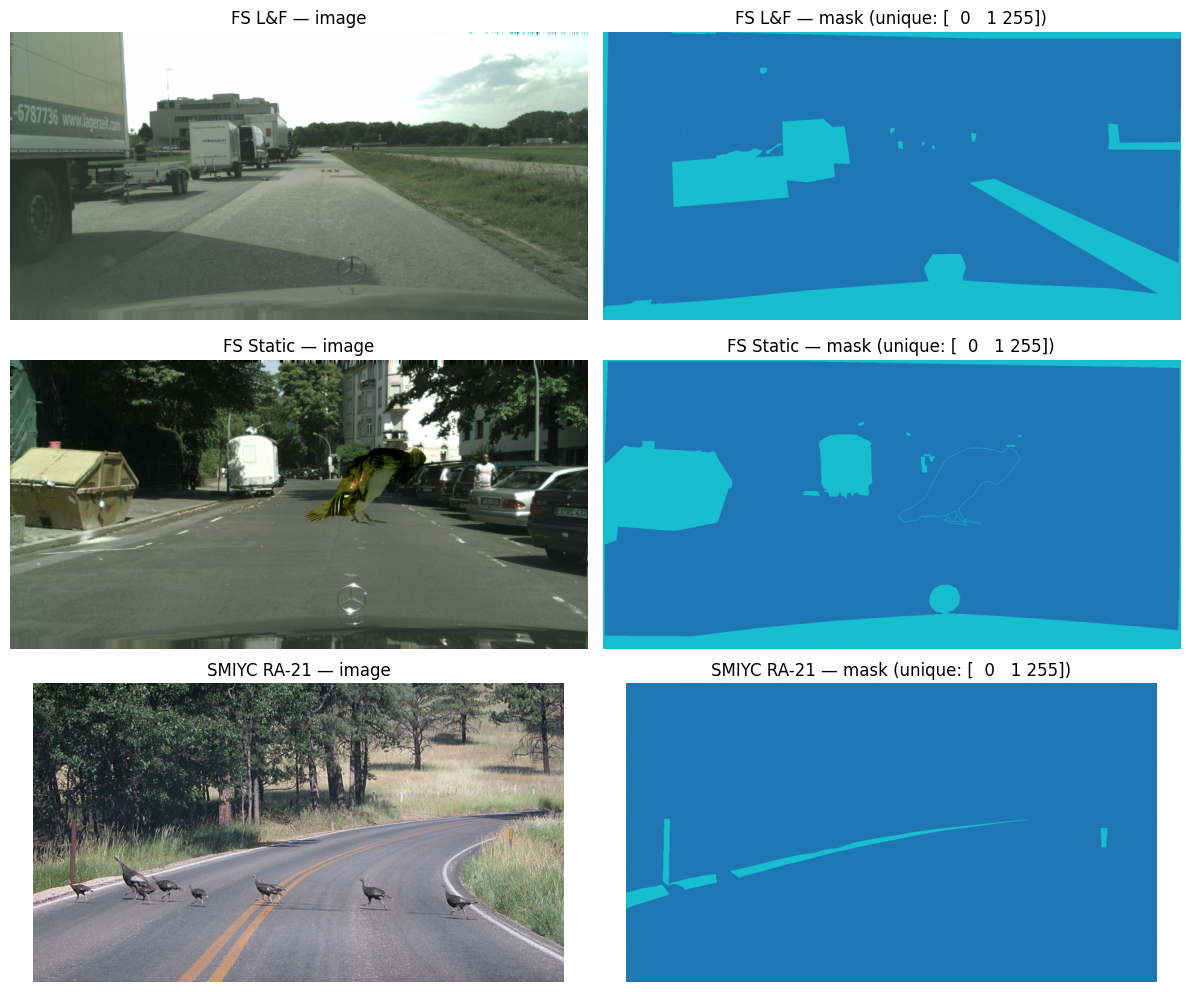

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import glob

# Visualize a sample from each dataset
datasets_to_check = {
    'FS L&F':    'eval/Validation_Dataset/FS_LostFound_full',
    'FS Static': 'eval/Validation_Dataset/fs_static',
    'SMIYC RA-21': 'eval/Validation_Dataset/RoadAnomaly21',
}

fig, axes = plt.subplots(len(datasets_to_check), 2, figsize=(12, 10))

for i, (name, root) in enumerate(datasets_to_check.items()):
    img_path = sorted(glob.glob(f'{root}/images/*'))[0]
    mask_path = sorted(glob.glob(f'{root}/labels_masks/*.png'))[0]

    img = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'{name} — image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='tab10')
    axes[i, 1].set_title(f'{name} — mask (unique: {np.unique(mask)})')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
for name, root in datasets_to_check.items():
    mask_paths = sorted(glob.glob(f'{root}/labels_masks/*.png'))
    sizes = []
    for p in mask_paths:
        m = np.array(Image.open(p))
        anomaly_pixels = (m == 1).sum()
        total_valid = ((m == 0) | (m == 1)).sum()
        if total_valid > 0:
            sizes.append(100 * anomaly_pixels / total_valid)
    print(f'{name}: mean anomaly % per image = {np.mean(sizes):.2f}%, median = {np.median(sizes):.2f}%')

FS L&F: mean anomaly % per image = 0.28%, median = 0.07%
FS Static: mean anomaly % per image = 1.38%, median = 0.95%
SMIYC RA-21: mean anomaly % per image = 14.76%, median = 9.57%


FS L&F sample 0: 0.050% anomalous, mask unique values: [  0   1 255]
FS L&F sample 5: 0.002% anomalous, mask unique values: [  0   1 255]
FS Static sample 0: 2.954% anomalous, mask unique values: [  0   1 255]
FS Static sample 5: 4.729% anomalous, mask unique values: [  0   1 255]


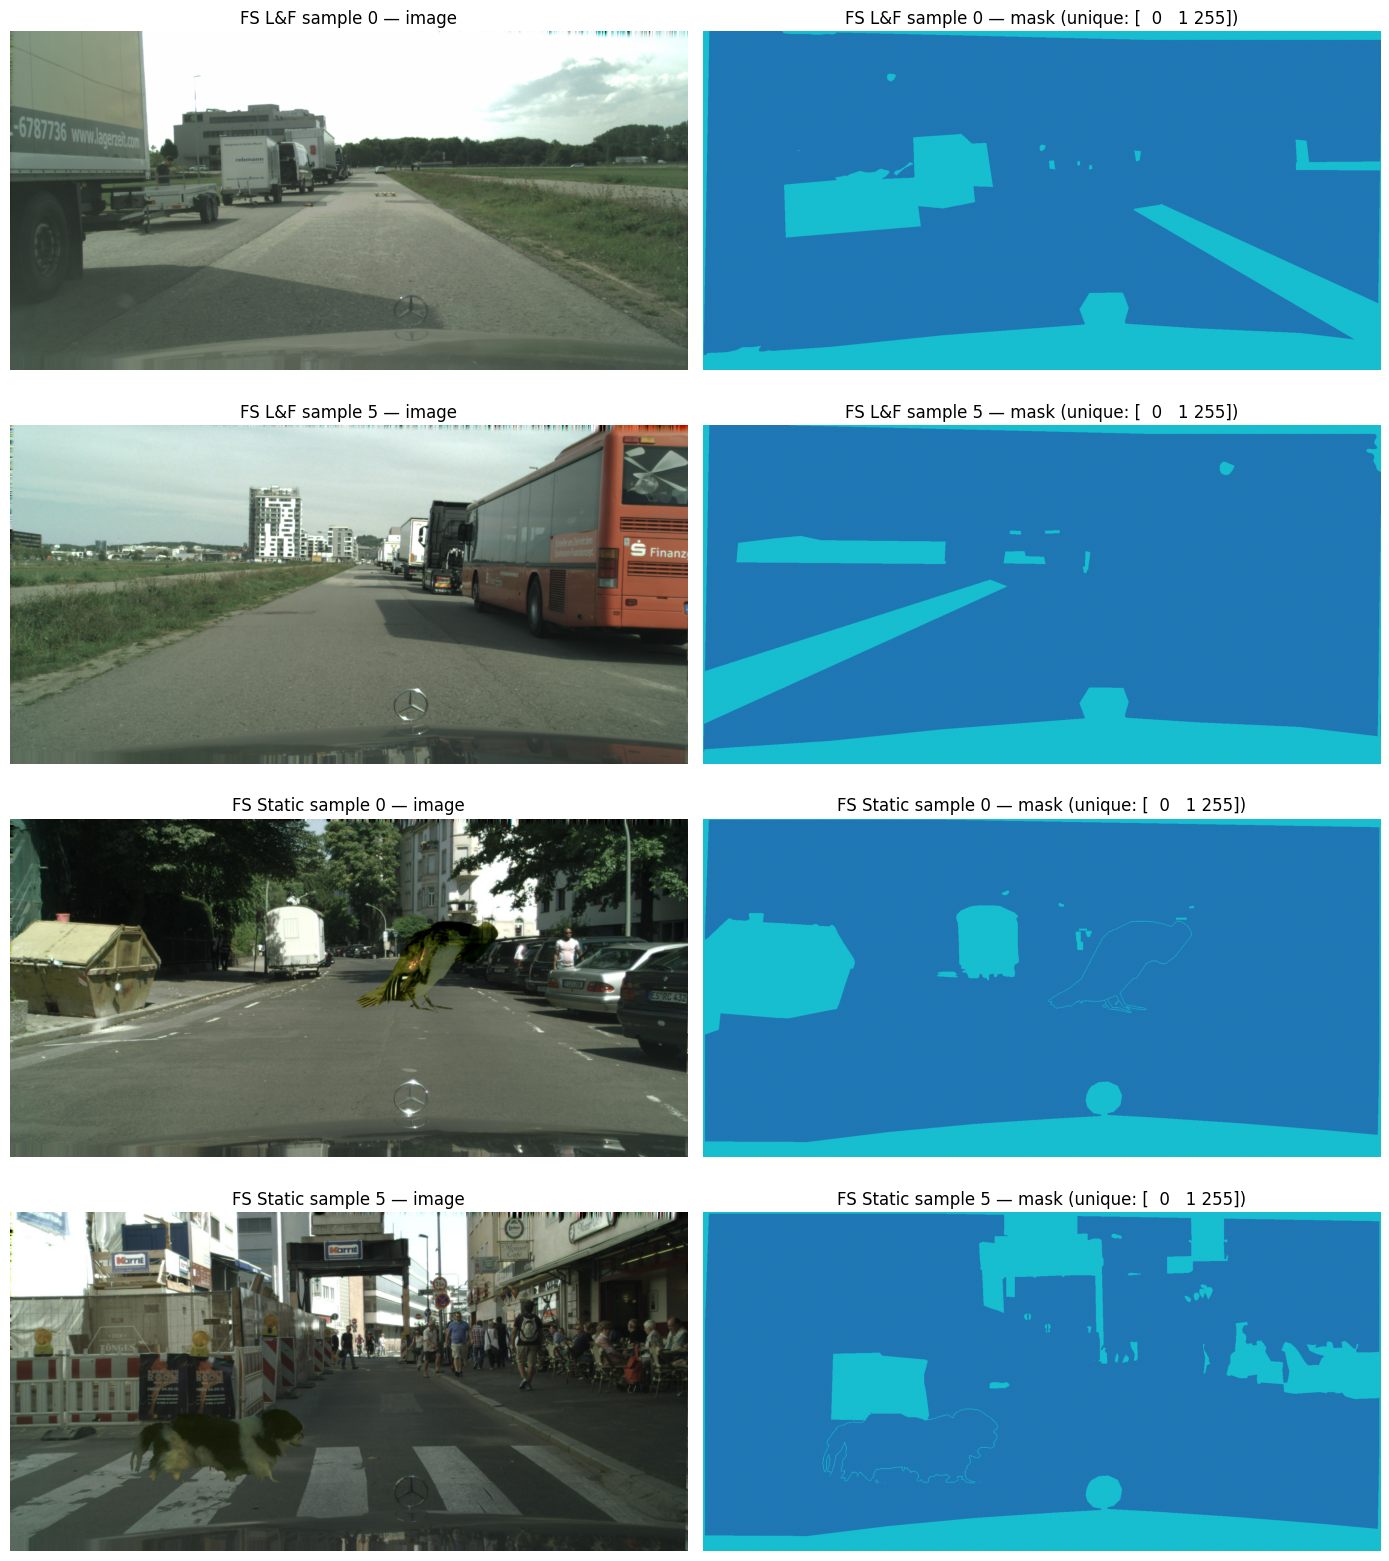

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import glob

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for row, (name, root) in enumerate([
    ('FS L&F',   'eval/Validation_Dataset/FS_LostFound_full'),
    ('FS Static','eval/Validation_Dataset/fs_static'),
]):
    img_paths  = sorted(glob.glob(f'{root}/images/*'))
    mask_paths = sorted(glob.glob(f'{root}/labels_masks/*.png'))

    for col, idx in enumerate([0, 5]):  # two different samples
        img  = np.array(Image.open(img_paths[idx]).convert('RGB'))
        mask = np.array(Image.open(mask_paths[idx]))

        ax_img  = axes[row*2 + col, 0]
        ax_mask = axes[row*2 + col, 1]

        ax_img.imshow(img)
        ax_img.set_title(f'{name} sample {idx} — image')
        ax_img.axis('off')

        ax_mask.imshow(mask, cmap='tab10', vmin=0, vmax=255)
        ax_mask.set_title(f'{name} sample {idx} — mask (unique: {np.unique(mask)})')
        ax_mask.axis('off')

        anomaly_pct = 100 * (mask == 1).sum() / ((mask == 0) | (mask == 1)).sum()
        print(f'{name} sample {idx}: {anomaly_pct:.3f}% anomalous, mask unique values: {np.unique(mask)}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image
import glob

datasets_to_check = {
    'SMIYC RA-21':  'eval/Validation_Dataset/RoadAnomaly21',
    'SMIYC RO-21':  'eval/Validation_Dataset/RoadObstacle21',
    'FS L&F':       'eval/Validation_Dataset/FS_LostFound_full',
    'FS Static':    'eval/Validation_Dataset/fs_static',
    'Road Anomaly': 'eval/Validation_Dataset/RoadAnomaly',
}

for name, root in datasets_to_check.items():
    mask_paths = sorted(glob.glob(f'{root}/labels_masks/*.png'))
    sizes = []
    for p in mask_paths:
        m = np.array(Image.open(p))
        anomaly = (m == 1).sum()
        valid = ((m == 0) | (m == 1)).sum()
        if valid > 0 and anomaly > 0:  # only images that have anomalies
            sizes.append(100 * anomaly / valid)

    sizes = np.array(sizes)
    print(f'{name}:')
    print(f'  images with anomalies: {len(sizes)}/{len(mask_paths)}')
    print(f'  mean:   {sizes.mean():.3f}%')
    print(f'  median: {np.median(sizes):.3f}%')
    print(f'  min:    {sizes.min():.3f}%')
    print(f'  max:    {sizes.max():.3f}%')
    print(f'  <0.1%:  {(sizes < 0.1).sum()} images')
    print(f'  <1%:    {(sizes < 1.0).sum()} images')
    print()

SMIYC RA-21:
  images with anomalies: 10/10
  mean:   14.758%
  median: 9.568%
  min:    1.687%
  max:    36.758%
  <0.1%:  0 images
  <1%:    0 images

SMIYC RO-21:
  images with anomalies: 30/30
  mean:   0.721%
  median: 0.292%
  min:    0.010%
  max:    5.357%
  <0.1%:  7 images
  <1%:    23 images

FS L&F:
  images with anomalies: 99/100
  mean:   0.281%
  median: 0.071%
  min:    0.001%
  max:    2.360%
  <0.1%:  57 images
  <1%:    91 images

FS Static:
  images with anomalies: 20/30
  mean:   2.065%
  median: 1.663%
  min:    0.613%
  max:    4.729%
  <0.1%:  0 images
  <1%:    5 images

Road Anomaly:
  images with anomalies: 0/60
  mean:   nan%
  median: nan%


/tmp/ipykernel_51144/1639747336.py:26: RuntimeWarning: Mean of empty slice.
  print(f'  mean:   {sizes.mean():.3f}%')
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
for name, root in datasets_to_check.items():
    mask_paths = sorted(glob.glob(f'{root}/labels_masks/*.png'))
    sizes = []
    for p in mask_paths:
        m = np.array(Image.open(p))

        # Apply correct mapping per dataset
        if 'RoadAnomaly' in p and '21' not in p:
            m = np.where(m == 2, 1, m)  # 2→1 anomaly

        anomaly = (m == 1).sum()
        valid = ((m == 0) | (m == 1)).sum()
        if valid > 0 and anomaly > 0:
            sizes.append(100 * anomaly / valid)

    sizes = np.array(sizes)
    if len(sizes) == 0:
        print(f'{name}: no anomaly images found — check label mapping')
        continue

    print(f'{name}:')
    print(f'  images with anomalies: {len(sizes)}/{len(mask_paths)}')
    print(f'  mean:   {sizes.mean():.3f}%')
    print(f'  median: {np.median(sizes):.3f}%')
    print(f'  min:    {sizes.min():.3f}%')
    print(f'  max:    {sizes.max():.3f}%')
    print(f'  <0.1%:  {(sizes < 0.1).sum()} images')
    print(f'  <1%:    {(sizes < 1.0).sum()} images')
    print()

SMIYC RA-21:
  images with anomalies: 10/10
  mean:   14.758%
  median: 9.568%
  min:    1.687%
  max:    36.758%
  <0.1%:  0 images
  <1%:    0 images

SMIYC RO-21:
  images with anomalies: 30/30
  mean:   0.721%
  median: 0.292%
  min:    0.010%
  max:    5.357%
  <0.1%:  7 images
  <1%:    23 images

FS L&F:
  images with anomalies: 99/100
  mean:   0.281%
  median: 0.071%
  min:    0.001%
  max:    2.360%
  <0.1%:  57 images
  <1%:    91 images

FS Static:
  images with anomalies: 20/30
  mean:   2.065%
  median: 1.663%
  min:    0.613%
  max:    4.729%
  <0.1%:  0 images
  <1%:    5 images

Road Anomaly:
  images with anomalies: 59/60
  mean:   9.679%
  median: 6.602%
  min:    0.375%
  max:    42.329%
  <0.1%:  0 images
  <1%:    6 images



## Temperature Scaling

Search for the best softmax temperature `T` using cached Fine-tuned logits
on Road Anomaly as calibration set.  Once `best_t` is found, **all MSP and
Max Entropy results are re-scored** with that temperature so the final table
reflects the calibrated numbers.

In [8]:
import numpy as np

temps = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]

# ── Temperature search on Fine-tuned model, Road Anomaly ──────────────────
print('── Temperature search: Fine-tuned × Road Anomaly ──')
calib_cache = get_cache_dir('Fine-tuned', 'Road Anomaly')
search_results = fast_temperature_search(calib_cache, scoring_fn=get_mask_msp,
                                         temperatures=temps)

best_t = max(search_results, key=lambda t: search_results[t]['auprc'])

df_temp = pd.DataFrame([
    {'T': t,
     'AuPRC': f"{search_results[t]['auprc']:.4f}",
     'FPR95': f"{search_results[t]['fpr95']:.4f}",
     'Best':  '✅' if t == best_t else ''}
    for t in temps
])
print(f'Best T = {best_t}')
display(df_temp)

# ── Apply best T to Fine-tuned model only ────────────────────────────────
if best_t != 1.0:
    print(f'\nRe-scoring Fine-tuned MSP, Max Entropy and RbA with T={best_t}...')
    for ds_name in mask_results['Fine-tuned']:
        cache_dir = get_cache_dir('Fine-tuned', ds_name)
        for method in ['MSP', 'Max Entropy', 'RbA']:
            mask_results['Fine-tuned'][ds_name][f'{method} (T={best_t})'] = \
                score_from_cache(cache_dir, method, temperature=best_t)

# ── Rebuild table ─────────────────────────────────────────────────────────
rows = []
for mn in mask_results:
    for ds in mask_results[mn]:
        for m in mask_results[mn][ds]:
            row = {'model': mn, 'dataset': ds, 'method': m}
            row.update(mask_results[mn][ds][m])
            rows.append(row)

df_mask = pd.DataFrame(rows).set_index(['model', 'dataset', 'method'])
print(df_mask.to_string())

── Temperature search: Fine-tuned × Road Anomaly ──
Testing Temperature T=0.5...
  T=0.5 -> AuPRC: 0.4985 | FPR95: 0.3267
Testing Temperature T=0.75...
  T=0.75 -> AuPRC: 0.6651 | FPR95: 0.2906
Testing Temperature T=1.0...
  T=1.0 -> AuPRC: 0.7387 | FPR95: 0.2669
Testing Temperature T=1.25...
  T=1.25 -> AuPRC: 0.7657 | FPR95: 0.2497
Testing Temperature T=1.5...
  T=1.5 -> AuPRC: 0.7677 | FPR95: 0.2334
Testing Temperature T=1.75...
  T=1.75 -> AuPRC: 0.7573 | FPR95: 0.2226
Testing Temperature T=2.0...
  T=2.0 -> AuPRC: 0.7537 | FPR95: 0.2032
Testing Temperature T=2.25...
  T=2.25 -> AuPRC: 0.7553 | FPR95: 0.1896
Testing Temperature T=2.5...
  T=2.5 -> AuPRC: 0.7556 | FPR95: 0.1785
Best T = 1.5


,T,AuPRC,FPR95,Best
0,0.50,0.4985,0.3267,
1,0.75,0.6651,0.2906,
2,1.00,0.7387,0.2669,
3,1.25,0.7657,0.2497,
4,1.50,0.7677,0.2334,✅
5,1.75,0.7573,0.2226,
6,2.00,0.7537,0.2032,
7,2.25,0.7553,0.1896,
8,2.50,0.7556,0.1785,



Re-scoring Fine-tuned MSP, Max Entropy and RbA with T=1.5...
                                                auprc     fpr95
model      dataset      method                                 
COCO       SMIYC RA-21  MSP                  0.179206  0.896242
                        MaxLogit             0.289128  0.758361
                        Max Entropy          0.218061  0.895675
                        RbA                  0.551400  0.724167
           SMIYC RO-21  MSP                  0.035511  1.000000
                        MaxLogit             0.284960  0.999955
                        Max Entropy          0.155657  1.000000
                        RbA                  0.375158  1.000000
           FS L&F       MSP                  0.032078  0.523937
                        MaxLogit             0.015881  0.910245
                        Max Entropy          0.029768  0.663451
                        RbA                  0.011250  0.827207
           FS Static    MSP               

## Results Summary

In [9]:
print("\n=== ERFNet Pixel Results ===")
print(df_pixel.to_string())
print("\n=== EoMT Mask Results (T=1.0 + calibrated) ===")
print(df_mask.to_string())



=== ERFNet Pixel Results ===
                             auprc     fpr95
SMIYC RA-21  MSP          0.290951  0.625492
             MaxLogit     0.383196  0.593371
             Max Entropy  0.309686  0.626583
SMIYC RO-21  MSP          0.027100  0.652250
             MaxLogit     0.046266  0.484434
             Max Entropy  0.030444  0.659116
FS L&F       MSP          0.017320  0.505626
             MaxLogit     0.032811  0.454526
             Max Entropy  0.025623  0.501268
FS Static    MSP          0.050333  0.409047
             MaxLogit     0.062681  0.396529
             Max Entropy  0.058881  0.406379
Road Anomaly MSP          0.120461  0.825716
             MaxLogit     0.153668  0.721441
             Max Entropy  0.123409  0.827198

=== EoMT Mask Results (T=1.0 + calibrated) ===
                                                auprc     fpr95
model      dataset      method                                 
COCO       SMIYC RA-21  MSP                  0.179206  0.896242
          